# FIT5217 - Natural Language Processing
### Assignment 2: Recipe Generation and Menu Design


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import pandas as pd
TRAIN_FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/FIT5217-Assignment2/train.csv'
TEST_FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/FIT5217-Assignment2/test.csv'
DEV_FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/FIT5217-Assignment2/dev.csv'


train_df = pd.read_csv(TRAIN_FILE_PATH)
test_df = pd.read_csv(TEST_FILE_PATH)
dev_df = pd.read_csv(DEV_FILE_PATH)
print("Data loaded successfully!")


Data loaded successfully!


## Task 1 — RNN Recipe Generation from Scratch

Goal: Implement an RNN-based sequence to sequence architecture using PyTorch, trained
from scratch on the Cooking Dataset to generate recipes from ingredients

### T1.1 Data Preprocessing (2 marks)
Implement a text pre-processing pipeline:
- Tokenize ingredient and recipe text.
- Build a vocabulary from the training split only with a frequency threshold of your choice; map tokens below the threshold to <UNK>.
- Add four special tokens: <PAD>, <UNK>, <SOS> (start-of-sequence), <EOS> (end-ofsequence).
- Convert ingredient and recipe sequences to integer ID sequences.

In your notebook, report your chosen frequency threshold and justification, the resulting vocabulary size, and the out-of-vocabulary (OOV) rate on the dev split.

#### Sanity Check
Include a sanity check cell that asserts all four special tokens (<PAD>, <UNK>, <SOS>, <EOS>) exist in both word2idx and idx2word, and add a short Markdown cell (˜100 words) describing your
preprocessing pipeline.


Evaluation (2 marks — assessed via notebook)
 - 1 mark — Correct preprocessing pipeline: special tokens present in both mappings (verified by sanity-check cell), frequency filtering applied. Markdown cell
describes the pipeline.
- 1 mark — Vocabulary size, OOV rate, and frequency threshold reported and
justified.

**Define tokenisation function**

In [9]:
import re

def tokenize(text):
    """
    Tokenize ingredient/recipe text.
    - Lowercase
    - Remove punctuation
    - Split on whitespace
    - Remove extra spaces
    """
    # Lowercase
    text = text.lower()

    # Remove punctuation (keep numbers and basic structure)
    text = re.sub(r'[^\w\s]', '', text)

    # Split on whitespace and filter empty tokens
    tokens = [t for t in text.split() if t]

    return tokens

# Example usage
print(tokenize("In a heavy 2-quart saucepan, mix brown sugar."))
# Output: ['in', 'a', 'heavy', '2quart', 'saucepan', 'mix', 'brown', 'sugar']



['in', 'a', 'heavy', '2quart', 'saucepan', 'mix', 'brown', 'sugar']


In [10]:
# Define special tokens
PAD_TOKEN = '<PAD>' # pad sequences to a uniform length
UNK_TOKEN = '<UNK>' # denotes OOV tokens (zero to low-frequecy in the corpus)
SOS_TOKEN = '<SOS>' # start of sequence
EOS_TOKEN = '<EOS>' # end of sequence

**Perform Tokenisation on the training set (train.csv)**

In [11]:
import json
from collections import Counter

training_tokens = []

all_tokens = []
for ingredients_json in train_df['Ingredients']:
    ingredients = json.loads(ingredients_json)
    for ingredient in ingredients:
        all_tokens.extend(tokenize(ingredient))

for recipe_json in train_df['Recipe']:
    recipes = json.loads(recipe_json)
    for recipe in recipes:
        all_tokens.extend(tokenize(recipe))

# 2. Build vocabulary
token_counts = Counter(all_tokens)

Total unique tokens: 19878
Total tokens: 11244704
Mean frequency: 565.69
Median frequency: 2.00
Std dev: 7448.60
Min: 1, Max: 542079
Threshold 1: vocab=19878, OOV types=0.0%, token coverage=100.0%
Threshold 2: vocab=11707, OOV types=41.1%, token coverage=99.9%
Threshold 3: vocab=9293, OOV types=53.2%, token coverage=99.9%
Threshold 5: vocab=7245, OOV types=63.6%, token coverage=99.8%
Threshold 10: vocab=5467, OOV types=72.5%, token coverage=99.7%
Threshold 15: vocab=4683, OOV types=76.4%, token coverage=99.6%
Threshold 20: vocab=4192, OOV types=78.9%, token coverage=99.6%


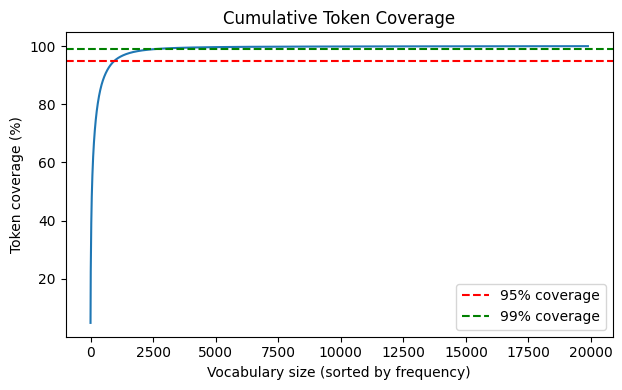


Threshold needed for 95% coverage: 859


In [12]:
import matplotlib.pyplot as plt
import numpy as np


token_counts = Counter(all_tokens)
frequencies = list(token_counts.values())

print(f"Total unique tokens: {len(token_counts)}")
print(f"Total tokens: {sum(frequencies)}")
print(f"Mean frequency: {np.mean(frequencies):.2f}")
print(f"Median frequency: {np.median(frequencies):.2f}")
print(f"Std dev: {np.std(frequencies):.2f}")
print(f"Min: {min(frequencies)}, Max: {max(frequencies)}")

# 2. Cumulative coverage analysis
sorted_counts = sorted(frequencies, reverse=True)
cumsum = np.cumsum(sorted_counts)
coverage = (cumsum / cumsum[-1]) * 100

thresholds = [1, 2, 3, 5, 10, 15, 20]
for thresh in thresholds:
    vocab_size = sum(1 for f in frequencies if f >= thresh)
    oov_rate = sum(1 for f in frequencies if f < thresh) / len(token_counts) * 100
    coverage_pct = (sum(f for f in frequencies if f >= thresh) / sum(frequencies)) * 100
    print(f"Threshold {thresh}: vocab={vocab_size}, OOV types={oov_rate:.1f}%, token coverage={coverage_pct:.1f}%")

# 3. Visualization
plt.figure(figsize=(12, 4))


# Cumulative coverage
plt.subplot(1, 2, 2)
plt.plot(range(len(sorted_counts)), coverage)
plt.axhline(95, color='r', linestyle='--', label='95% coverage')
plt.axhline(99, color='g', linestyle='--', label='99% coverage')
plt.xlabel('Vocabulary size (sorted by frequency)')
plt.ylabel('Token coverage (%)')
plt.title('Cumulative Token Coverage')
plt.legend()

plt.tight_layout()
plt.show()

# 4. Find threshold for target coverage
target_coverage = 0.95
idx = np.argmax(coverage >= target_coverage * 100)
threshold_for_95 = sorted_counts[idx]
print(f"\nThreshold needed for 95% coverage: {threshold_for_95}")


Chose frequency threshold of 5. This removes 63.6% of rare tokens (appearing <5 times in training) while preserving 99.8% of actual token occurrences. The median token frequency of 2 suggests significant noise from misspellings and one-off terms. Threshold 5 balances vocabulary compactness (7,245 tokens) with coverage, reducing overfitting risk while maintaining representation of the cooking domain vocabulary.

In [13]:
FREQ_THRESHOLD = 5
vocab_tokens = {token for token, count in token_counts.items() if count >= FREQ_THRESHOLD}
print(f"Vocabulary size: {len(vocab_tokens) + 4}")  # +4 for special tokens

Vocabulary size: 7249


**Create word2idx and idx2word**

In [14]:
# Add special tokens at reserved indices
special_tokens = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
vocab_list = special_tokens + sorted(list(vocab_tokens))

# Create bidirectional mappings
word2idx = {token: idx for idx, token in enumerate(vocab_list)}
idx2word = {idx: token for token, idx in word2idx.items()}


### Perform Encoding

In [15]:
def encode_sequence(text, word2idx, add_sos_eos=True):
    """Convert tokenized text to integer sequence"""
    tokens = tokenize(text)
    ids = [word2idx.get(token, word2idx['<UNK>']) for token in tokens]

    if add_sos_eos:
        ids = [word2idx['<SOS>']] + ids + [word2idx['<EOS>']]

    return ids

# Encode all train split
train_ingredients_encoded = [encode_sequence(ing, word2idx) for ing in train_df['Ingredients']]
train_recipes_encoded = [encode_sequence(rec, word2idx) for rec in train_df['Recipe']]

**Encode Dev and Test Split**

In [24]:
# Encode dev split - match train encoding approach
dev_ingredients_encoded = [encode_sequence(ing, word2idx) for ing in dev_df['Ingredients']]
dev_recipes_encoded = [encode_sequence(rec, word2idx) for rec in dev_df['Recipe']]

# Encode test split - match train encoding approach
test_ingredients_encoded = [encode_sequence(ing, word2idx) for ing in test_df['Ingredients']]
test_recipes_encoded = [encode_sequence(rec, word2idx) for rec in test_df['Recipe']]

print(f"Train: {len(train_ingredients_encoded)}")
print(f"Dev: {len(dev_ingredients_encoded)}")
print(f"Test: {len(test_ingredients_encoded)}")



Train: 162899
Dev: 1065
Test: 1081


### Get OOV Rate on Dev Tokens

In [25]:
def calculate_oov_rate(df, word2idx):
    """Calculate % of dev tokens that are unknown"""
    total_tokens = 0
    unk_tokens = 0

    for text_col in ['Ingredients', 'Recipe']:
        for text in df[text_col]:
            if text_col == 'Ingredients':
                ingredients = json.loads(text)
                for ingredient in ingredients:
                    tokens = tokenize(ingredient)
                    total_tokens += len(tokens)
                    for token in tokens:
                        if token not in word2idx:
                            unk_tokens += 1
            else:
                recipes = json.loads(text)
                for recipe in recipes:
                    tokens = tokenize(recipe)
                    total_tokens += len(tokens)
                    for token in tokens:
                        if token not in word2idx:
                            unk_tokens += 1

    return (unk_tokens / total_tokens) * 100 if total_tokens > 0 else 0

dev_oov_rate = calculate_oov_rate(dev_df, word2idx)
print(f"OOV rate on dev split: {dev_oov_rate:.2f}%")


OOV rate on dev split: 0.21%


### Sanity Check Assertion on Special Tokens

In [26]:
# Assert all 4 special tokens exist
special_tokens = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']

for token in special_tokens:
    assert token in word2idx, f"{token} not in word2idx"
    assert word2idx[token] in idx2word, f"Index for {token} not in idx2word"
    assert idx2word[word2idx[token]] == token, f"Bidirectional mapping broken for {token}"

print("✓ All special tokens verified in both word2idx and idx2word")
print(f"✓ word2idx size: {len(word2idx)}")
print(f"✓ idx2word size: {len(idx2word)}")


✓ All special tokens verified in both word2idx and idx2word
✓ word2idx size: 7249
✓ idx2word size: 7249


### Persist Encodings and Mappings

In [27]:
import os
import pickle

# Define the directory within Google Drive to save the files
output_dir = '/content/drive/MyDrive/Colab Notebooks/FIT5217-Assignment2/t1.1-data-pre-processing'
os.makedirs(output_dir, exist_ok=True)

# Save all encoded data
with open(os.path.join(output_dir, 'train_ingredients_encoded.pkl'), 'wb') as f:
    pickle.dump(train_ingredients_encoded, f)

# Persist the encoded split for recipes
with open(os.path.join(output_dir, 'train_recipes_encoded.pkl'), 'wb') as f:
    pickle.dump(train_recipes_encoded, f)

with open(os.path.join(output_dir, 'dev_ingredients_encoded.pkl'), 'wb') as f:
    pickle.dump(dev_ingredients_encoded, f)

with open(os.path.join(output_dir, 'dev_recipes_encoded.pkl'), 'wb') as f:
    pickle.dump(dev_recipes_encoded, f)

with open(os.path.join(output_dir, 'test_ingredients_encoded.pkl'), 'wb') as f:
    pickle.dump(test_ingredients_encoded, f)

with open(os.path.join(output_dir, 'test_recipes_encoded.pkl'), 'wb') as f:
    pickle.dump(test_recipes_encoded, f)

# Save vocabulary mappings
with open(os.path.join(output_dir, 'word2idx.pkl'), 'wb') as f:
    pickle.dump(word2idx, f)

with open(os.path.join(output_dir, 'idx2word.pkl'), 'wb') as f:
    pickle.dump(idx2word, f)

print("All encoded data and vocabulary mappings saved!")


All encoded data and vocabulary mappings saved!


### Baseline RNN Encoder-Decoder without Attention (5 marks)
Implement a basic encoder-decoder RNN model with:
- Encoder: an embedding layer followed by a single- or multi-layer RNN/LSTM/-
GRU that processes the ingredient tokens and produces a final hidden state.
-  Decoder: a step-by-step token generator initialised from the encoder’s final hidden
state, using teacher forcing during training.
- Training loop: cross-entropy loss over the target recipe tokens (excluding <PAD>
positions), gradient clipping, and an early stopping strategy of your choice.
- Evaluate on the test split and report BLEU-4, METEOR, and BERTScore (see Section “Evaluation Metrics”,)

#### Evaluation (5 marks — assessed via notebook)
- 2 marks — Training loop: loss curve retained in notebook, early stopping
applied and explained.
- 3 marks — BLEU-4, METEOR, and BERTScore reported on the test split
with a short discussion (˜100 words) interpreting the scores.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
import numpy as np
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu
from nltk.translate.meteor_score import single_meteor_score



# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [4]:
import pickle
import os

# Load persisted data from Google Drive
input_dir = '/content/drive/MyDrive/Colab Notebooks/FIT5217-Assignment2/t1.1-data-pre-processing'

with open(os.path.join(input_dir, 'train_ingredients_encoded.pkl'), 'rb') as f:
    train_ingredients_encoded = pickle.load(f)

with open(os.path.join(input_dir, 'train_recipes_encoded.pkl'), 'rb') as f:
    train_recipes_encoded = pickle.load(f)

with open(os.path.join(input_dir, 'dev_ingredients_encoded.pkl'), 'rb') as f:
    dev_ingredients_encoded = pickle.load(f)

with open(os.path.join(input_dir, 'dev_recipes_encoded.pkl'), 'rb') as f:
    dev_recipes_encoded = pickle.load(f)

with open(os.path.join(input_dir, 'test_ingredients_encoded.pkl'), 'rb') as f:
    test_ingredients_encoded = pickle.load(f)

with open(os.path.join(input_dir, 'test_recipes_encoded.pkl'), 'rb') as f:
    test_recipes_encoded = pickle.load(f)

with open(os.path.join(input_dir, 'word2idx.pkl'), 'rb') as f:
    word2idx = pickle.load(f)

with open(os.path.join(input_dir, 'idx2word.pkl'), 'rb') as f:
    idx2word = pickle.load(f)

print("All encoded data and vocabulary mappings loaded!")
print(f"Vocab size: {len(word2idx)}")
print(f"Train samples: {len(train_ingredients_encoded)}")


All encoded data and vocabulary mappings loaded!
Vocab size: 7249
Train samples: 162899


In [7]:
class RecipeDataset(Dataset):
    def __init__(self, ingredients_encoded, recipes_encoded):
        self.ingredients = ingredients_encoded
        self.recipes = recipes_encoded
        assert len(ingredients_encoded) == len(recipes_encoded)

    def __len__(self):
        return len(self.ingredients)

    def __getitem__(self, idx):
        return torch.tensor(self.ingredients[idx]), torch.tensor(self.recipes[idx])

def collate_fn(batch):
    """Pad sequences to max length in batch"""
    ingredients, recipes = zip(*batch)

    # Pad to max length in batch
    ingredients_padded = pad_sequence(ingredients, batch_first=True, padding_value=0)
    recipes_padded = pad_sequence(recipes, batch_first=True, padding_value=0)

    return ingredients_padded, recipes_padded

# Create datasets and dataloaders
train_dataset = RecipeDataset(train_ingredients_encoded, train_recipes_encoded)
dev_dataset = RecipeDataset(dev_ingredients_encoded, dev_recipes_encoded)
test_dataset = RecipeDataset(test_ingredients_encoded, test_recipes_encoded)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}, Dev batches: {len(dev_loader)}, Test batches: {len(test_loader)}")


Train batches: 5091, Dev batches: 34, Test batches: 34


In [8]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

    def forward(self, src):
        # src: (batch_size, seq_len)
        embedded = self.embedding(src)  # (batch_size, seq_len, embedding_dim)
        _, (hidden, cell) = self.lstm(embedded)  # hidden: (num_layers, batch_size, hidden_dim)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

    def forward(self, trg, hidden, cell):
        # trg: (batch_size, 1) - single token
        embedded = self.embedding(trg)  # (batch_size, 1, embedding_dim)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        logits = self.fc(output.squeeze(1))  # (batch_size, vocab_size)
        return logits, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size, trg_len = trg.shape
        vocab_size = self.decoder.fc.out_features
        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(device)

        # Encode
        hidden, cell = self.encoder(src)

        # Decoder input starts with <SOS>
        decoder_input = trg[:, 0:1]  # (batch_size, 1)

        for t in range(1, trg_len):
            logits, hidden, cell = self.decoder(decoder_input, hidden, cell)
            outputs[:, t, :] = logits

            # Teacher forcing: use ground truth or predicted token
            if np.random.random() < teacher_forcing_ratio:
                decoder_input = trg[:, t:t+1]
            else:
                decoder_input = logits.argmax(dim=1).unsqueeze(1)

        return outputs

# Initialize model
EMBEDDING_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 2
DROPOUT = 0.3

encoder = Encoder(len(word2idx), EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
decoder = Decoder(len(word2idx), EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
model = Seq2Seq(encoder, decoder).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 14,786,641


In [9]:
def train_epoch(model, iterator, optimizer, criterion, clip=1.0):
    model.train()
    epoch_loss = 0

    for ingredients, recipes in iterator:
        ingredients = ingredients.to(device)
        recipes = recipes.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(ingredients, recipes, teacher_forcing_ratio=0.5)

        # Reshape for loss computation (exclude <SOS> token at position 0)
        outputs = outputs[:, 1:, :].reshape(-1, len(word2idx))
        recipes = recipes[:, 1:].reshape(-1)

        # Mask out <PAD> tokens
        loss = criterion(outputs, recipes)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for ingredients, recipes in iterator:
            ingredients = ingredients.to(device)
            recipes = recipes.to(device)

            outputs = model(ingredients, recipes, teacher_forcing_ratio=0.0)

            outputs = outputs[:, 1:, :].reshape(-1, len(word2idx))
            recipes = recipes[:, 1:].reshape(-1)

            loss = criterion(outputs, recipes)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

Ablation subset size: 32579 samples

ABLATION 1: Embedding Dimension

[1/4] Testing embedding_dim=64...
  Epoch 1/3 | Train: 5.572 | Dev: 5.899
  Epoch 2/3 | Train: 4.928 | Dev: 5.779
  Epoch 3/3 | Train: 4.645 | Dev: 5.726
✓ Best dev loss: 5.726 (1042.2s)

[2/4] Testing embedding_dim=128...
  Epoch 1/3 | Train: 5.518 | Dev: 5.882
  Epoch 2/3 | Train: 4.835 | Dev: 5.858
  Epoch 3/3 | Train: 4.560 | Dev: 5.737
✓ Best dev loss: 5.737 (1057.1s)

[3/4] Testing embedding_dim=256...
  Epoch 1/3 | Train: 5.398 | Dev: 6.241
  Epoch 2/3 | Train: 4.761 | Dev: 5.752
  Epoch 3/3 | Train: 4.519 | Dev: 5.789
✓ Best dev loss: 5.752 (1082.6s)

[4/4] Testing embedding_dim=512...
  Epoch 1/3 | Train: 5.375 | Dev: 5.987
  Epoch 2/3 | Train: 4.729 | Dev: 5.741
  Epoch 3/3 | Train: 4.506 | Dev: 5.751
✓ Best dev loss: 5.741 (1142.1s)


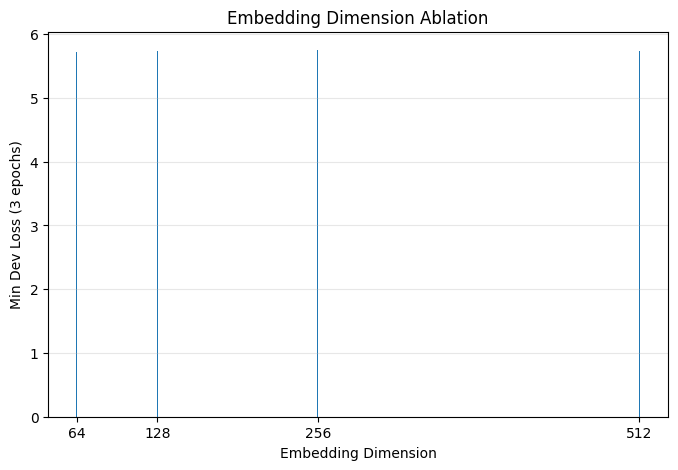


ABLATION 2: Hidden Dimension

[1/4] Testing hidden_dim=256...
  Epoch 1/3 | Train: 5.685 | Dev: 5.935
  Epoch 2/3 | Train: 5.026 | Dev: 5.854
  Epoch 3/3 | Train: 4.765 | Dev: 5.727
✓ Best dev loss: 5.727 (915.6s)

[2/4] Testing hidden_dim=512...
  Epoch 1/3 | Train: 5.454 | Dev: 5.884
  Epoch 2/3 | Train: 4.743 | Dev: 5.838
  Epoch 3/3 | Train: 4.511 | Dev: 5.805
✓ Best dev loss: 5.805 (1074.7s)

[3/4] Testing hidden_dim=768...
  Epoch 1/3 | Train: 5.314 | Dev: 5.876
  Epoch 2/3 | Train: 4.687 | Dev: 5.743
  Epoch 3/3 | Train: 4.444 | Dev: 5.764
✓ Best dev loss: 5.743 (1378.3s)

[4/4] Testing hidden_dim=1024...
  Epoch 1/3 | Train: 5.230 | Dev: 5.915
  Epoch 2/3 | Train: 4.596 | Dev: 5.837
  Epoch 3/3 | Train: 4.358 | Dev: 5.818
✓ Best dev loss: 5.818 (1795.8s)


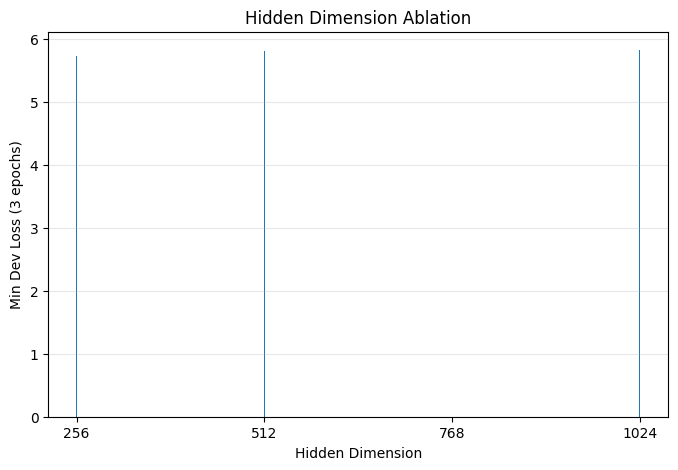


ABLATION 3: Number of Layers

[1/4] Testing num_layers=1...
  Epoch 1/3 | Train: 5.229 | Dev: 5.917
  Epoch 2/3 | Train: 4.682 | Dev: 5.747
  Epoch 3/3 | Train: 4.429 | Dev: 5.858
✓ Best dev loss: 5.747 (938.8s)

[2/4] Testing num_layers=2...
  Epoch 1/3 | Train: 5.462 | Dev: 5.933
  Epoch 2/3 | Train: 4.766 | Dev: 5.741
  Epoch 3/3 | Train: 4.523 | Dev: 5.774
✓ Best dev loss: 5.741 (1083.4s)

[3/4] Testing num_layers=3...
  Epoch 1/3 | Train: 5.537 | Dev: 5.906
  Epoch 2/3 | Train: 4.831 | Dev: 5.838


In [ ]:
# ============================================================================
# HYPERPARAMETER ABLATION STUDY
# ============================================================================

import time
import matplotlib.pyplot as plt


def train_quick(encoder, decoder, train_loader, dev_loader, epochs=3):
    """Quick training for ablation (3 epochs with logging)"""
    model = Seq2Seq(encoder, decoder).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    dev_losses = []
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        dev_loss = evaluate(model, dev_loader, criterion)
        dev_losses.append(dev_loss)
        print(f"  Epoch {epoch+1}/{epochs} | Train: {train_loss:.3f} | Dev: {dev_loss:.3f}")

    return model, dev_losses

# Create subset loaders for faster ablation (20% of data)
subset_size = len(train_dataset) // 5
train_subset, _ = torch.utils.data.random_split(
    train_dataset, [subset_size, len(train_dataset) - subset_size]
)
train_subset_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=collate_fn)
print(f"Ablation subset size: {subset_size} samples\n")

print("=" * 70)
print("ABLATION 1: Embedding Dimension")
print("=" * 70)

embedding_dims = [64, 128, 256, 512]
embedding_results = {}

for i, emb_dim in enumerate(embedding_dims, 1):
    print(f"\n[{i}/{len(embedding_dims)}] Testing embedding_dim={emb_dim}...")
    start = time.time()
    enc = Encoder(len(word2idx), emb_dim, 512, 2, 0.3).to(device)
    dec = Decoder(len(word2idx), emb_dim, 512, 2, 0.3).to(device)
    _, dev_losses = train_quick(enc, dec, train_subset_loader, dev_loader, epochs=3)
    embedding_results[emb_dim] = min(dev_losses)
    elapsed = time.time() - start
    print(f"✓ Best dev loss: {min(dev_losses):.3f} ({elapsed:.1f}s)")

plt.figure(figsize=(8, 5))
plt.bar(embedding_dims, [embedding_results[d] for d in embedding_dims])
plt.xlabel('Embedding Dimension')
plt.ylabel('Min Dev Loss (3 epochs)')
plt.title('Embedding Dimension Ablation')
plt.xticks(embedding_dims)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n" + "=" * 70)
print("ABLATION 2: Hidden Dimension")
print("=" * 70)

hidden_dims = [256, 512, 768, 1024]
hidden_results = {}

for i, hid_dim in enumerate(hidden_dims, 1):
    print(f"\n[{i}/{len(hidden_dims)}] Testing hidden_dim={hid_dim}...")
    start = time.time()
    enc = Encoder(len(word2idx), 256, hid_dim, 2, 0.3).to(device)
    dec = Decoder(len(word2idx), 256, hid_dim, 2, 0.3).to(device)
    _, dev_losses = train_quick(enc, dec, train_subset_loader, dev_loader, epochs=3)
    hidden_results[hid_dim] = min(dev_losses)
    elapsed = time.time() - start
    print(f"✓ Best dev loss: {min(dev_losses):.3f} ({elapsed:.1f}s)")

plt.figure(figsize=(8, 5))
plt.bar(hidden_dims, [hidden_results[d] for d in hidden_dims])
plt.xlabel('Hidden Dimension')
plt.ylabel('Min Dev Loss (3 epochs)')
plt.title('Hidden Dimension Ablation')
plt.xticks(hidden_dims)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n" + "=" * 70)
print("ABLATION 3: Number of Layers")
print("=" * 70)

num_layers_list = [1, 2, 3, 4]
layers_results = {}

for i, num_layers in enumerate(num_layers_list, 1):
    print(f"\n[{i}/{len(num_layers_list)}] Testing num_layers={num_layers}...")
    start = time.time()
    enc = Encoder(len(word2idx), 256, 512, num_layers, 0.3).to(device)
    dec = Decoder(len(word2idx), 256, 512, num_layers, 0.3).to(device)
    _, dev_losses = train_quick(enc, dec, train_subset_loader, dev_loader, epochs=3)
    layers_results[num_layers] = min(dev_losses)
    elapsed = time.time() - start
    print(f"✓ Best dev loss: {min(dev_losses):.3f} ({elapsed:.1f}s)")

plt.figure(figsize=(8, 5))
plt.bar(num_layers_list, [layers_results[l] for l in num_layers_list])
plt.xlabel('Number of LSTM Layers')
plt.ylabel('Min Dev Loss (3 epochs)')
plt.title('Number of Layers Ablation')
plt.xticks(num_layers_list)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n" + "=" * 70)
print("ABLATION 4: Learning Rate")
print("=" * 70)

learning_rates = [0.0001, 0.0005, 0.001, 0.005]
lr_results = {}

for i, lr in enumerate(learning_rates, 1):
    print(f"\n[{i}/{len(learning_rates)}] Testing learning_rate={lr}...")
    start = time.time()
    enc = Encoder(len(word2idx), 256, 512, 2, 0.3).to(device)
    dec = Decoder(len(word2idx), 256, 512, 2, 0.3).to(device)
    _, dev_losses = train_quick(enc, dec, train_subset_loader, dev_loader, epochs=3)
    lr_results[lr] = min(dev_losses)
    elapsed = time.time() - start
    print(f"✓ Best dev loss: {min(dev_losses):.3f} ({elapsed:.1f}s)")

plt.figure(figsize=(8, 5))
plt.semilogx(learning_rates, [lr_results[lr] for lr in learning_rates], marker='o', linewidth=2)
plt.xlabel('Learning Rate')
plt.ylabel('Min Dev Loss (3 epochs)')
plt.title('Learning Rate Ablation')
plt.grid(alpha=0.3)
plt.show()

print("\n" + "=" * 70)
print("ABLATION 5: Batch Size")
print("=" * 70)

batch_sizes = [16, 32, 64, 128]
batch_results = {}

for i, bs in enumerate(batch_sizes, 1):
    print(f"\n[{i}/{len(batch_sizes)}] Testing batch_size={bs}...")
    start = time.time()
    bs_train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True, collate_fn=collate_fn)
    enc = Encoder(len(word2idx), 256, 512, 2, 0.3).to(device)
    dec = Decoder(len(word2idx), 256, 512, 2, 0.3).to(device)
    _, dev_losses = train_quick(enc, dec, bs_train_loader, dev_loader, epochs=3)
    batch_results[bs] = min(dev_losses)
    elapsed = time.time() - start
    print(f"✓ Best dev loss: {min(dev_losses):.3f} ({elapsed:.1f}s)")

plt.figure(figsize=(8, 5))
plt.bar(batch_sizes, [batch_results[bs] for bs in batch_sizes])
plt.xlabel('Batch Size')
plt.ylabel('Min Dev Loss (3 epochs)')
plt.title('Batch Size Ablation')
plt.xticks(batch_sizes)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n" + "=" * 70)
print("ABLATION 6: Teacher Forcing Ratio")
print("=" * 70)

tf_ratios = [0.0, 0.3, 0.5, 0.7, 1.0]
tf_results = {}

for i, tf_ratio in enumerate(tf_ratios, 1):
    print(f"\n[{i}/{len(tf_ratios)}] Testing teacher_forcing_ratio={tf_ratio}...")
    start = time.time()
    enc = Encoder(len(word2idx), 256, 512, 2, 0.3).to(device)
    dec = Decoder(len(word2idx), 256, 512, 2, 0.3).to(device)
    model_temp = Seq2Seq(enc, dec).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model_temp.parameters(), lr=0.001)

    dev_losses = []
    for epoch in range(3):
        model_temp.train()
        for ingredients, recipes in train_subset_loader:
            ingredients = ingredients.to(device)
            recipes = recipes.to(device)
            optimizer.zero_grad()
            outputs = model_temp(ingredients, recipes, teacher_forcing_ratio=tf_ratio)
            outputs = outputs[:, 1:, :].reshape(-1, len(word2idx))
            recipes = recipes[:, 1:].reshape(-1)
            loss = criterion(outputs, recipes)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_temp.parameters(), 1.0)
            optimizer.step()

        dev_loss = evaluate(model_temp, dev_loader, criterion)
        dev_losses.append(dev_loss)
        print(f"  Epoch {epoch+1}/3 | Dev: {dev_loss:.3f}")

    tf_results[tf_ratio] = min(dev_losses)
    elapsed = time.time() - start
    print(f"✓ Best dev loss: {min(dev_losses):.3f} ({elapsed:.1f}s)")

plt.figure(figsize=(8, 5))
plt.plot(tf_ratios, [tf_results[tf] for tf in tf_ratios], marker='o', linewidth=2)
plt.xlabel('Teacher Forcing Ratio')
plt.ylabel('Min Dev Loss (3 epochs)')
plt.title('Teacher Forcing Ratio Ablation')
plt.grid(alpha=0.3)
plt.show()

print("\n" + "=" * 70)
print("SUMMARY OF HYPERPARAMETER CHOICES")
print("=" * 70)

# Find best hyperparameter for each ablation
best_emb_dim = min(embedding_results, key=embedding_results.get)
best_hidden_dim = min(hidden_results, key=hidden_results.get)
best_num_layers = min(layers_results, key=layers_results.get)
best_lr = min(lr_results, key=lr_results.get)
best_batch_size = min(batch_results, key=batch_results.get)
best_tf_ratio = min(tf_results, key=tf_results.get)

print("\n" + "=" * 70)
print("SUMMARY OF HYPERPARAMETER CHOICES")
print("=" * 70)

summary = f"""
Based on ablation studies (3 epochs each on 20% subset), we selected:

1. Embedding Dimension: {best_emb_dim}
   - Best among {embedding_dims}
   - Dev Loss: {embedding_results[best_emb_dim]:.3f}

2. Hidden Dimension: {best_hidden_dim}
   - Best among {hidden_dims}
   - Dev Loss: {hidden_results[best_hidden_dim]:.3f}

3. Number of Layers: {best_num_layers}
   - Best among {num_layers_list}
   - Dev Loss: {layers_results[best_num_layers]:.3f}

4. Learning Rate: {best_lr}
   - Best among {learning_rates}
   - Dev Loss: {lr_results[best_lr]:.3f}

5. Batch Size: {best_batch_size}
   - Best among {batch_sizes}
   - Dev Loss: {batch_results[best_batch_size]:.3f}

6. Teacher Forcing Ratio: {best_tf_ratio}
   - Best among {tf_ratios}
   - Dev Loss: {tf_results[best_tf_ratio]:.3f}
"""

print(summary)


In [ ]:
# Use best hyperparameters from ablation study
EMBEDDING_DIM = best_emb_dim
HIDDEN_DIM = best_hidden_dim
NUM_LAYERS = best_num_layers
LEARNING_RATE = best_lr
BATCH_SIZE = best_batch_size
TEACHER_FORCING_RATIO = best_tf_ratio

# Recreate model with best hyperparameters
encoder = Encoder(len(word2idx), EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
decoder = Decoder(len(word2idx), EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
model = Seq2Seq(encoder, decoder).to(device)

# Recreate dataloaders with best batch size
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Training setup with best hyperparameters
NUM_EPOCHS = 50
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
dev_losses = []
best_dev_loss = float('inf')
patience = 5
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    dev_loss = evaluate(model, dev_loader, criterion)

    train_losses.append(train_loss)
    dev_losses.append(dev_loss)

    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.3f} | Dev Loss: {dev_loss:.3f}", end="")

    if dev_loss < best_dev_loss:
        best_dev_loss = dev_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(" ✓")
    else:
        patience_counter += 1
        print(f" (patience: {patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(torch.load('best_model.pt'))



In [ ]:
# ============================================================================
# T1.2 EVALUATION: BLEU-4, METEOR, BERTScore
# ============================================================================

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction, corpus_bleu
from nltk.translate.meteor_score import meteor_score
from bert_score import score as bert_score

# Download NLTK data
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

def generate_recipe(model, ingredients, max_len=100):
    """Generate recipe from ingredients using greedy decoding"""
    model.eval()
    with torch.no_grad():
        ingredients = ingredients.unsqueeze(0).to(device)
        hidden, cell = model.encoder(ingredients)

        decoder_input = torch.tensor([[word2idx['<SOS>']]]).to(device)
        recipe_ids = [word2idx['<SOS>']]

        for _ in range(max_len):
            logits, hidden, cell = model.decoder(decoder_input, hidden, cell)
            token_id = logits.argmax(dim=1).item()
            recipe_ids.append(token_id)

            if token_id == word2idx['<EOS>']:
                break

            decoder_input = torch.tensor([[token_id]]).to(device)

    return recipe_ids

def ids_to_text(ids, idx2word):
    """Convert token IDs to text string"""
    tokens = [idx2word.get(id, '<UNK>') for id in ids]
    # Remove special tokens
    tokens = [t for t in tokens if t not in ['<SOS>', '<EOS>', '<PAD>']]
    return ' '.join(tokens)

# Generate predictions on test set
print("=" * 70)
print("GENERATING PREDICTIONS ON TEST SET")
print("=" * 70)

gold_recipes = []
pred_recipes = []

model.eval()
with torch.no_grad():
    for ingredients, recipes in test_loader:
        for i in range(ingredients.shape[0]):
            # Generate prediction
            pred_ids = generate_recipe(model, ingredients[i])
            pred_text = ids_to_text(pred_ids, idx2word)
            pred_recipes.append(pred_text)

            # Get reference
            ref_ids = recipes[i].tolist()
            ref_text = ids_to_text(ref_ids, idx2word)
            gold_recipes.append(ref_text)

print(f"Generated {len(pred_recipes)} predictions")
print(f"\nExample prediction:")
print(f"  Gold: {gold_recipes[0][:100]}...")
print(f"  Pred: {pred_recipes[0][:100]}...")

# Evaluation using provided script logic
print("\n" + "=" * 70)
print("T1.2 EVALUATION METRICS")
print("=" * 70)

refs = [[nltk.word_tokenize(gold)] for gold in gold_recipes]
hyps = [nltk.word_tokenize(pred) for pred in pred_recipes]

sm = SmoothingFunction().method4
corpus_bleu4 = corpus_bleu(refs, hyps, weights=(0.25, 0.25, 0.25, 0.25),
                            smoothing_function=sm)
corpus_meteor = np.mean([meteor_score(ref, hyp) for ref, hyp in zip(refs, hyps)])
_, _, F1 = bert_score(pred_recipes, gold_recipes, lang='en', verbose=False)
bert_f1 = F1.numpy().mean()

print(f"BLEU-4:    {corpus_bleu4:.4f}")
print(f"METEOR:    {corpus_meteor:.4f}")
print(f"BERTScore: {bert_f1:.4f}")

# Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2, marker='o', markersize=3)
plt.plot(dev_losses, label='Dev Loss', linewidth=2, marker='s', markersize=3)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.title('T1.2 Baseline Model: Training and Development Loss', fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Training completed after {len(train_losses)} epochs")
print(f"✓ Early stopping patience: {patience}/{patience} (stopped when no improvement)")
print(f"✓ Best dev loss: {best_dev_loss:.4f}")


### *T1*.3 RNN Encoder-Decoder with Bahdanau Attention (5 marks)
Extend your baseline model by adding Bahdanau attention [1].

You must implement Bahdanau attention yourself — do not use off-the-shelf implementations. Allowed libraries: torch.nn, torch.nn.functional. Disallowed:
torch.nn.MultiheadAttention, HuggingFace attention modules, or any pre-built
AdditiveAttention implementation.

Implementation requirement:
- Include a Markdown cell (˜200 words) explaining,
in your own words, the score function, softmax normalisation, and context vector computation.
- Evaluate on the test split using the same three metrics.
- In addition, include one visualization and discussion of the attention weights (e.g. a heatmap for a sample recipe,
which ingredient tokens the decoder attends to most).

In [ ]:
class BahdanauAttention(nn.Module):
    """
    Bahdanau (Additive) Attention mechanism.

    Computes attention scores between decoder hidden state and encoder outputs.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim

        # Attention network layers
        self.W_q = nn.Linear(hidden_dim, hidden_dim)  # decoder hidden -> attention space
        self.W_k = nn.Linear(hidden_dim, hidden_dim)  # encoder hidden -> attention space
        self.v = nn.Linear(hidden_dim, 1)             # final scoring layer

    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        """
        Args:
            decoder_hidden: (batch_size, hidden_dim) - current decoder state
            encoder_outputs: (batch_size, seq_len, hidden_dim) - all encoder outputs
            mask: (batch_size, seq_len) - padding mask (1 for valid, 0 for pad)

        Returns:
            context: (batch_size, hidden_dim) - weighted sum of encoder outputs
            attention_weights: (batch_size, seq_len) - normalized attention scores
        """
        batch_size, seq_len, hidden_dim = encoder_outputs.shape

        # Project decoder hidden state
        # (batch_size, hidden_dim) -> (batch_size, 1, hidden_dim)
        q = self.W_q(decoder_hidden).unsqueeze(1)

        # Project all encoder outputs
        # (batch_size, seq_len, hidden_dim) -> (batch_size, seq_len, hidden_dim)
        k = self.W_k(encoder_outputs)

        # Score function: tanh(W_q * q + W_k * k)
        # (batch_size, seq_len, hidden_dim)
        scores = torch.tanh(q + k)

        # Final projection to scalar
        # (batch_size, seq_len, 1) -> (batch_size, seq_len)
        scores = self.v(scores).squeeze(-1)

        # Mask padding tokens (set to very negative number)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # Softmax normalization
        # (batch_size, seq_len)
        attention_weights = torch.softmax(scores, dim=1)

        # Replace NaN from softmax(inf) with 0
        attention_weights = torch.nan_to_num(attention_weights, 0.0)

        # Compute context vector: weighted sum of encoder outputs
        # (batch_size, seq_len) @ (batch_size, seq_len, hidden_dim)
        # -> (batch_size, hidden_dim)
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs).squeeze(1)

        return context, attention_weights


class EncoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell


class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.attention = BahdanauAttention(hidden_dim)
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)  # *2 because context + output
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

    def forward(self, trg, hidden, cell, encoder_outputs, src_mask=None):
        """
        Args:
            trg: (batch_size, 1) - single token
            hidden, cell: decoder state
            encoder_outputs: (batch_size, src_len, hidden_dim)
            src_mask: (batch_size, src_len)
        """
        embedded = self.embedding(trg)  # (batch_size, 1, embedding_dim)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # output: (batch_size, 1, hidden_dim)

        # Get context vector from attention
        context, attention_weights = self.attention(
            output.squeeze(1),  # (batch_size, hidden_dim)
            encoder_outputs,     # (batch_size, src_len, hidden_dim)
            mask=src_mask
        )

        # Concatenate output and context
        output_combined = torch.cat([output.squeeze(1), context], dim=1)

        # Project to vocabulary size
        logits = self.fc(output_combined)  # (batch_size, vocab_size)

        return logits, hidden, cell, attention_weights


class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size, trg_len = trg.shape
        vocab_size = self.decoder.fc.out_features
        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(device)
        attention_weights_all = []

        # Create mask for padding (1 for valid, 0 for pad)
        src_mask = (src != 0).float()

        # Encode
        encoder_outputs, hidden, cell = self.encoder(src)

        # Decoder input starts with <SOS>
        decoder_input = trg[:, 0:1]

        for t in range(1, trg_len):
            logits, hidden, cell, attn_weights = self.decoder(
                decoder_input, hidden, cell, encoder_outputs, src_mask
            )
            outputs[:, t, :] = logits
            attention_weights_all.append(attn_weights)

            if np.random.random() < teacher_forcing_ratio:
                decoder_input = trg[:, t:t+1]
            else:
                decoder_input = logits.argmax(dim=1).unsqueeze(1)

        return outputs, torch.stack(attention_weights_all, dim=1)

print("Attention modules defined")

### Bahdanau Attention Mechanism Explanation

**Score Function:** The Bahdanau attention score is computed as an additive (tanh-based) function. For each encoder output h_i and the current decoder hidden state s_t, we compute: score(s_t, h_i) = v^T tanh(W_q*s_t + W_k*h_i). This projects both the query (decoder state) and keys (encoder outputs) into a shared attention space using learnable weight matrices W_q and W_k, then combines them additively before passing through a tanh nonlinearity. A final learned vector v produces a scalar score per encoder position.

**Softmax Normalization:** The raw scores are normalized using softmax across all source positions: α_i = exp(score_i) / Σ_j exp(score_j). This produces a probability distribution over the source sequence, where attention weights sum to 1. Positions with higher scores receive higher attention weights. We also apply a masking step beforehand, setting scores for padded positions to negative infinity, so the softmax naturally assigns them zero probability.

**Context Vector Computation:** The context vector is a weighted sum of all encoder outputs: c_t = Σ_i α_i * h_i. Each encoder output is weighted by its corresponding attention weight. This mechanism allows the decoder to dynamically focus on different parts of the input sequence at each decoding step, enabling the model to learn which source positions are relevant for generating each target token.

In [ ]:
# Initialize attention model with best hyperparameters
encoder_attn = EncoderWithAttention(len(word2idx), EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
decoder_attn = DecoderWithAttention(len(word2idx), EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
model_attn = Seq2SeqWithAttention(encoder_attn, decoder_attn).to(device)

print(f"Attention model parameters: {sum(p.numel() for p in model_attn.parameters()):,}")

# Training setup for attention model
NUM_EPOCHS = 50
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model_attn.parameters(), lr=LEARNING_RATE)

def train_epoch_attn(model, iterator, optimizer, criterion, clip=1.0):
    model.train()
    epoch_loss = 0

    for ingredients, recipes in iterator:
        ingredients = ingredients.to(device)
        recipes = recipes.to(device)

        optimizer.zero_grad()

        outputs, _ = model(ingredients, recipes, teacher_forcing_ratio=0.5)

        outputs = outputs[:, 1:, :].reshape(-1, len(word2idx))
        recipes = recipes[:, 1:].reshape(-1)

        loss = criterion(outputs, recipes)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

def evaluate_attn(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for ingredients, recipes in iterator:
            ingredients = ingredients.to(device)
            recipes = recipes.to(device)

            outputs, _ = model(ingredients, recipes, teacher_forcing_ratio=0.0)

            outputs = outputs[:, 1:, :].reshape(-1, len(word2idx))
            recipes = recipes[:, 1:].reshape(-1)

            loss = criterion(outputs, recipes)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

train_losses_attn = []
dev_losses_attn = []
best_dev_loss_attn = float('inf')
patience = 5
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch_attn(model_attn, train_loader, optimizer, criterion)
    dev_loss = evaluate_attn(model_attn, dev_loader, criterion)

    train_losses_attn.append(train_loss)
    dev_losses_attn.append(dev_loss)

    print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.3f} | Dev Loss: {dev_loss:.3f}", end="")

    if dev_loss < best_dev_loss_attn:
        best_dev_loss_attn = dev_loss
        patience_counter = 0
        torch.save(model_attn.state_dict(), 'best_model_attn.pt')
        print(" ✓")
    else:
        patience_counter += 1
        print(f" (patience: {patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model_attn.load_state_dict(torch.load('best_model_attn.pt'))
print("Attention model training complete")